# VQE Algorithm based on the following publication:

Paper: https://pubs.acs.org/doi/10.1021/acs.jctc.4c01657

ESI: https://pubs.acs.org/doi/suppl/10.1021/acs.jctc.4c01657/suppl_file/ct4c01657_si_001.pdf

In [30]:
import time
import numpy as np
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import Aer, AerSimulator
from qiskit_aer.primitives import Sampler, EstimatorV2
from qiskit_algorithms import MinimumEigensolverResult
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA, POWELL
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [31]:
# The BeH2 molecule
driver = PySCFDriver(
atom = """ H -1.326, 0.0, 0.0
           Be 0.000, 0.0, 0.0
           H  1.326, 0.0, 0.0
       """,
basis = "sto3g",
charge = 0,
spin = 0
)
# Generating the Electronic Structure Problem
molecule_problem = driver.run()

In [32]:
# Reducing the problem to the active space containing the 2 electrons in the 3 spatial orbitals
active_space_transformer = ActiveSpaceTransformer(
num_electrons =2 , num_spatial_orbitals = 3
)
reduced_molecule_problem = active_space_transformer . transform ( molecule_problem )

In [33]:
# Obtaining the second quantized Hamiltonian
second_q_hamiltonian = reduced_molecule_problem.second_q_ops()[0]

In [34]:
# Defining the Parity mapper
# When the number of particles is given , 2 - qubit tapering is also applied
parity_mapper = ParityMapper(num_particles = reduced_molecule_problem.num_particles)
# Applying the Parity Mapping
qubit_op = parity_mapper.map(second_q_hamiltonian)

In [35]:
ansatz = EfficientSU2(num_qubits = qubit_op.num_qubits, entanglement = "linear", reps = 1)

In [36]:
# Creating a backend
backend = AerSimulator()

# Creating the pass manager that transpiles the ansatz
pm = generate_preset_pass_manager ( backend = backend , optimization_level = 0 )

# Transpiling the ansatz - ISA stands for " Instruction Set Architecture "
isa_ansatz = pm . run ( ansatz )

# Applying the layout of the ISA ansatz to the Hamiltonian observable
# This ensures that the observables qubits are the same as the ansatz qubits
isa_observables = qubit_op . apply_layout ( isa_ansatz . layout )

In [ ]:
# Getting the energy value by interpreting the expectation value
# in the context of the reduced molecule problem
def interpret_exp_val(exp_val, problem):
# Wrapping the expectation value in MinimumEigensolverResult
    sol = MinimumEigensolverResult()
    sol.eigenvalue = np.real(exp_val)
    # Interpreting the result
    return problem.interpret(sol).total_energies[0]

In [38]:
# Using the Estimator primitive (noiseless statevector simulator by default)
estimator = EstimatorV2()
# Defining the energy cost function
def energy_cost_function ( params ) :
    # Run the job and get the eigenvalue result
    estimator_job = estimator . run ( [ ( isa_ansatz , isa_observables , params ) ] )
    estimator_exp_val = estimator_job . result () [ 0 ] . data . evs
    # Return the interpreted energy value
    return interpret_exp_val ( estimator_exp_val , reduced_molecule_problem )

In [39]:
# Results list to store the energy values
results = []
# The callback function runs after each COBYLA iteration
def optimizer_callback(params):
    global results
    # Compute current energy at params (COBYLA callback only receives parameters)
    value = energy_cost_function(params)
    results.append(value)
    print(f"Iteration {len(results):03d} - Energy = {value}")

In [40]:
# Defining the COBYLA optimizer
optimizer = COBYLA(maxiter=1000, callback=optimizer_callback)

In [41]:
# Defining random initial parameters
initial_params = np.random.rand(ansatz.num_parameters)

In [42]:
# Running the VQE algorithm
# Classical COBYLA optimizer using the quantum cost function
result = optimizer.minimize(energy_cost_function, initial_params)
# Storing the final energy and parameters
energy_result, parameters_result = result.fun, result.x

Iteration 001 - Energy = -15.276973212406265
Iteration 002 - Energy = -15.276973212406265
Iteration 003 - Energy = -15.276973212406265
Iteration 004 - Energy = -15.276973212406265
Iteration 005 - Energy = -15.276973212406265
Iteration 006 - Energy = -15.277325699510861
Iteration 007 - Energy = -15.277325699510861
Iteration 008 - Energy = -15.277919055180664
Iteration 009 - Energy = -15.27825346142011
Iteration 010 - Energy = -15.280432648952328
Iteration 011 - Energy = -15.282399521947927
Iteration 012 - Energy = -15.282399521947927
Iteration 013 - Energy = -15.28240409719212
Iteration 014 - Energy = -15.28240409719212
Iteration 015 - Energy = -15.28240409719212
Iteration 016 - Energy = -15.287306336003823
Iteration 017 - Energy = -15.291086530229396
Iteration 018 - Energy = -15.293807008655126
Iteration 019 - Energy = -15.295696485882694
Iteration 020 - Energy = -15.300481083937584
Iteration 021 - Energy = -15.303040776772256
Iteration 022 - Energy = -15.304998827000098
Iteration 023 

In [43]:
# Bond scan: VQE energy vs Be–H bond distance
distances = np.linspace(1.0, 1.5, 15)  # in Angstrom
scan_energies = []
scan_convergence = []

# Previous optimal parameters for warm-starting the next geometry
prev_opt_params = None

for d in distances:
    # Define linear BeH2-like geometry with one scanned Be–H distance
    driver = PySCFDriver(
        atom=f""" H -1.36,   0.0, 0.0
                  Be 0.00,   0.0, 0.0
                  H {d:.6f}, 0.0, 0.0
              """,
        basis="sto3g",
        charge=0,
        spin=0,
    )
    
    # Electronic structure problem for this geometry
    molecule_problem = driver.run()
    active_space_transformer = ActiveSpaceTransformer(
        num_electrons=2, num_spatial_orbitals=3
    )
    reduced_molecule_problem = active_space_transformer.transform(molecule_problem)
    
    # Map to qubit Hamiltonian
    second_q_hamiltonian = reduced_molecule_problem.second_q_ops()[0]
    parity_mapper = ParityMapper(
        num_particles=reduced_molecule_problem.num_particles
    )
    qubit_op = parity_mapper.map(second_q_hamiltonian)
    
    # Ansatz for this qubit Hamiltonian
    ansatz = EfficientSU2(
        num_qubits=qubit_op.num_qubits, entanglement="linear", reps=1
    )
    
    # Backend and pass manager
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    isa_ansatz = pm.run(ansatz)
    
    # Maybe This is what we needed to do, it is described in the ESI section 4.4
    isa_observables = qubit_op.apply_layout(isa_ansatz.layout)
    
    # Estimator-based cost function for this geometry
    estimator = EstimatorV2()
    def energy_cost_function(params):
        estimator_job = estimator.run([(isa_ansatz, isa_observables, params)])
        estimator_exp_val = estimator_job.result()[0].data.evs
        return interpret_exp_val(estimator_exp_val, reduced_molecule_problem)
    
    # Track convergence for this distance
    energies_this_dist = []
    def optimizer_callback(xk):
        value = energy_cost_function(xk)
        energies_this_dist.append(value)
    
    # Initial parameters: random for first point, then warm-start from previous optimum
    if prev_opt_params is None:
        initial_params = np.random.rand(ansatz.num_parameters)
    else:
        initial_params = prev_opt_params
    
    # COBYLA optimization for this geometry
    optimizer = COBYLA(maxiter=1000, callback=optimizer_callback, tol=1e-6)
    result = optimizer.minimize(energy_cost_function, initial_params)
    energy = result.fun
    
    scan_energies.append(energy)
    scan_convergence.append(energies_this_dist)
    prev_opt_params = result.x
    
    print(f"d = {d:.3f} Å, E = {energy}")

d = 1.000 Å, E = -15.507030268199934
d = 1.036 Å, E = -15.521319312634898
d = 1.071 Å, E = -15.53278874354552
d = 1.107 Å, E = -15.54181931207222
d = 1.143 Å, E = -15.548715025099757
d = 1.179 Å, E = -15.553740292391533
d = 1.214 Å, E = -15.557126623493325
d = 1.250 Å, E = -15.559077677741268
d = 1.286 Å, E = -15.559774125622344
d = 1.321 Å, E = -15.559375771015333
d = 1.357 Å, E = -15.558022328529105
d = 1.393 Å, E = -15.555833189121596
d = 1.429 Å, E = -15.552909156232658
d = 1.464 Å, E = -15.549336335996214
d = 1.500 Å, E = -15.545190733951703


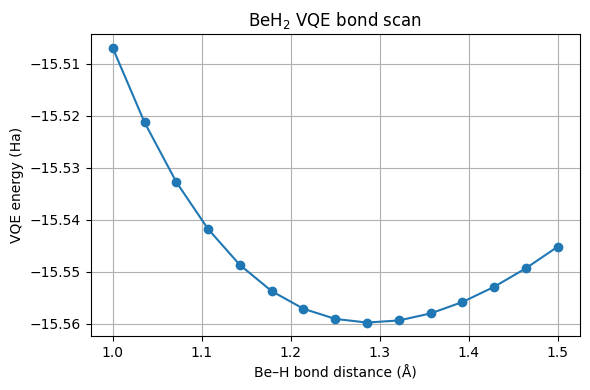

In [44]:
# Plot VQE bond scan results
plt.figure(figsize=(6, 4))
plt.plot(distances, scan_energies, marker="o")
plt.xlabel("Be–H bond distance (Å)")
plt.ylabel("VQE energy (Ha)")
plt.title("BeH$_2$ VQE bond scan")
plt.grid(True)
plt.tight_layout()
plt.show()

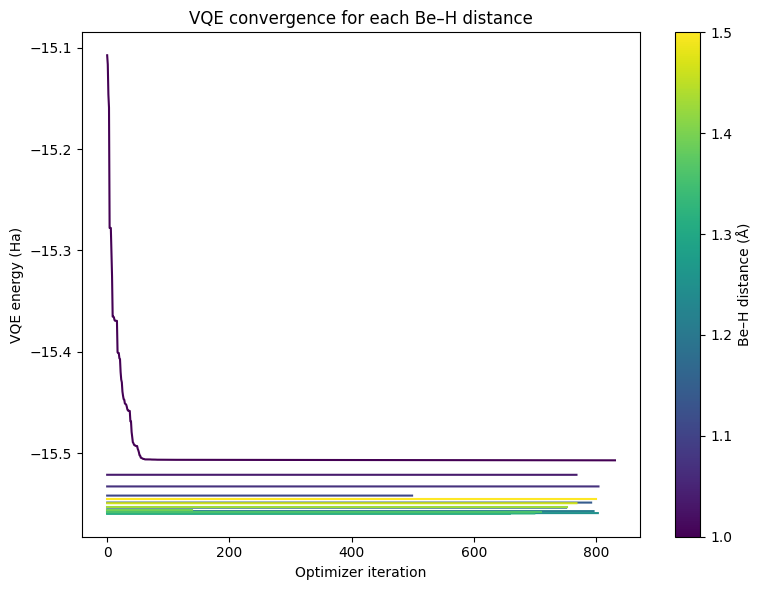

In [45]:
# Plot VQE convergence per bond distance (energy vs optimizer iteration)
plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=float(min(distances)), vmax=float(max(distances)))

for d, energies in zip(distances, scan_convergence):
    iters = range(len(energies))
    color = cmap(norm(float(d)))
    plt.plot(iters, energies, color=color)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.xlabel("Optimizer iteration")
plt.ylabel("VQE energy (Ha)")
plt.title("VQE convergence for each Be–H distance")

ax = plt.gca()
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Be–H distance (Å)")

plt.tight_layout()
plt.show()

## Joint optimization of Be–H distance and ansatz parameters

In addition to the bond scan, we can treat the Be–H distance as an additional classical variable and perform a joint optimization of the molecular geometry and the variational ansatz parameters.

We use a COBYLA optimizer acting on a parameter vector that contains all ansatz angles plus the Be–H distance, and we compare the optimized geometry to the discrete bond scan computed above.

In [ ]:
# Use a reference geometry to determine the number of ansatz parameters
ref_distance = 1.1  # Å
ref_driver = PySCFDriver(
    atom=f""" H -1.36,   0.0, 0.0
              Be 0.00,   0.0, 0.0
              H {ref_distance:.6f}, 0.0, 0.0
          """,
    basis="sto3g",
    charge=0,
    spin=0,
 )
ref_problem = ref_driver.run()
ref_active_space = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=3)
ref_reduced_problem = ref_active_space.transform(ref_problem)
ref_second_q_hamiltonian = ref_reduced_problem.second_q_ops()[0]
ref_parity_mapper = ParityMapper(num_particles=ref_reduced_problem.num_particles)
ref_qubit_op = ref_parity_mapper.map(ref_second_q_hamiltonian)
ref_ansatz = EfficientSU2(
    num_qubits=ref_qubit_op.num_qubits, entanglement="linear", reps=1,
 )
num_theta = ref_ansatz.num_parameters

# Define bounds for the Be–H distance (softly enforced via a penalty term)
d_min, d_max = 1.0, 1.5  # Å
penalty_strength = 100.0

# Containers to track optimization history
joint_eval_count = 0
joint_raw_energies = []
joint_penalized_energies = []
joint_distances = []

def vqe_energy_with_distance(theta, distance):
    """VQE energy for a given ansatz parameter vector and Be–H distance."""
    driver = PySCFDriver(
        atom=f""" H -1.36,   0.0, 0.0
                  Be 0.00,   0.0, 0.0
                  H {distance:.6f}, 0.0, 0.0
              """,
        basis="sto3g",
        charge=0,
        spin=0,
    )
    molecule_problem = driver.run()
    active_space_transformer = ActiveSpaceTransformer(
        num_electrons=2, num_spatial_orbitals=3
)
    reduced_molecule_problem = active_space_transformer.transform(molecule_problem)

    second_q_hamiltonian = reduced_molecule_problem.second_q_ops()[0]
    parity_mapper = ParityMapper(num_particles=reduced_molecule_problem.num_particles)
    qubit_op = parity_mapper.map(second_q_hamiltonian)

    ansatz = EfficientSU2(
        num_qubits=qubit_op.num_qubits, entanglement="linear", reps=1
)

    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    isa_ansatz = pm.run(ansatz)
    isa_observables = qubit_op.apply_layout(isa_ansatz.layout)

    estimator = EstimatorV2()
    estimator_job = estimator.run([(isa_ansatz, isa_observables, theta)])
    estimator_exp_val = estimator_job.result()[0].data.evs
    return interpret_exp_val(estimator_exp_val, reduced_molecule_problem)

def joint_cost_function(x):
    """Objective function for joint optimization over (theta, distance)."""
    global joint_eval_count, joint_raw_energies, joint_penalized_energies, joint_distances

    theta = x[:-1]
    distance = x[-1]

    # Raw VQE energy at this distance
    raw_energy = vqe_energy_with_distance(theta, distance)
    energy = raw_energy
    penalty = 0.0

    # Soft penalty for going outside the chosen distance window
    if distance < d_min:
        penalty = penalty_strength * (d_min - distance) ** 2
    elif distance > d_max:
        penalty = penalty_strength * (distance - d_max) ** 2

    energy += penalty

    # Bookkeeping and logging
    joint_eval_count += 1
    joint_raw_energies.append(raw_energy)
    joint_penalized_energies.append(energy)
    joint_distances.append(distance)
    print(
        f"Eval {joint_eval_count:03d}: d = {distance:.4f} Å, "
        f"raw E = {raw_energy:.8f} Ha, cost = {energy:.8f} Ha",
    )

    return energy

# Initial guess: random circuit parameters and a reasonable starting distance
np.random.seed(42)
initial_theta = np.random.rand(num_theta)
initial_distance = 1.1  # Å

x0 = np.concatenate([initial_theta, [initial_distance]])

# Run COBYLA in the joint parameter space so that all
# parameters, including the distance, are perturbed frequently
optimizer = COBYLA(maxiter=200, tol=1e-8)
joint_opt_result = optimizer.minimize(joint_cost_function, x0)

opt_theta = joint_opt_result.x[:-1]
opt_distance = joint_opt_result.x[-1]
opt_energy = joint_opt_result.fun

print(f"Optimized distance  : {opt_distance:.4f} Å")
print(f"Optimized VQE energy: {opt_energy:.8f} Ha")

Eval 001: d = 1.1000 Å, raw E = -14.80148961 Ha, cost = -14.80148961 Ha
Eval 002: d = 1.1000 Å, raw E = -14.91708345 Ha, cost = -14.91708345 Ha
Eval 003: d = 1.1000 Å, raw E = -14.72435346 Ha, cost = -14.72435346 Ha
Eval 004: d = 1.1000 Å, raw E = -15.00364430 Ha, cost = -15.00364430 Ha
Eval 005: d = 1.1000 Å, raw E = -14.84650915 Ha, cost = -14.84650915 Ha
Eval 006: d = 1.1000 Å, raw E = -14.97437345 Ha, cost = -14.97437345 Ha
Eval 007: d = 1.1000 Å, raw E = -14.95794982 Ha, cost = -14.95794982 Ha
Eval 008: d = 1.1000 Å, raw E = -14.88105530 Ha, cost = -14.88105530 Ha
Eval 009: d = 1.1000 Å, raw E = -15.10175834 Ha, cost = -15.10175834 Ha
Eval 010: d = 1.1000 Å, raw E = -15.08075772 Ha, cost = -15.08075772 Ha
Eval 011: d = 1.1000 Å, raw E = -15.12031954 Ha, cost = -15.12031954 Ha
Eval 012: d = 1.1000 Å, raw E = -15.21606666 Ha, cost = -15.21606666 Ha
Eval 013: d = 1.1000 Å, raw E = -15.14770792 Ha, cost = -15.14770792 Ha
Eval 014: d = 1.1000 Å, raw E = -15.21924556 Ha, cost = -15.2192

# Compare joint-optimized geometry to discrete bond scan

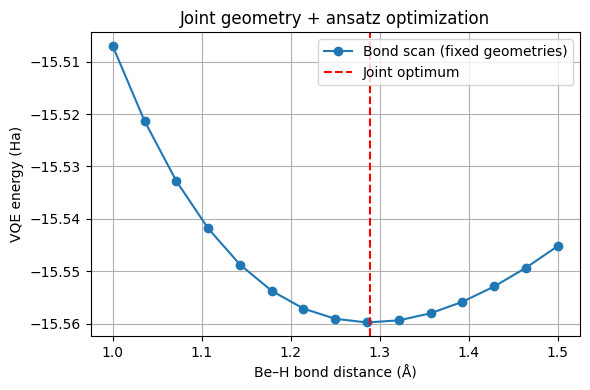

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(distances, scan_energies, "o-", label="Bond scan (fixed geometries)")
plt.axvline(opt_distance, color="red", linestyle="--", label="Joint optimum")
plt.xlabel("Be–H bond distance (Å)")
plt.ylabel("VQE energy (Ha)")
plt.title("Joint geometry + ansatz optimization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()